# Building a HR assistant using LLMs

## 1) Assistant Flow

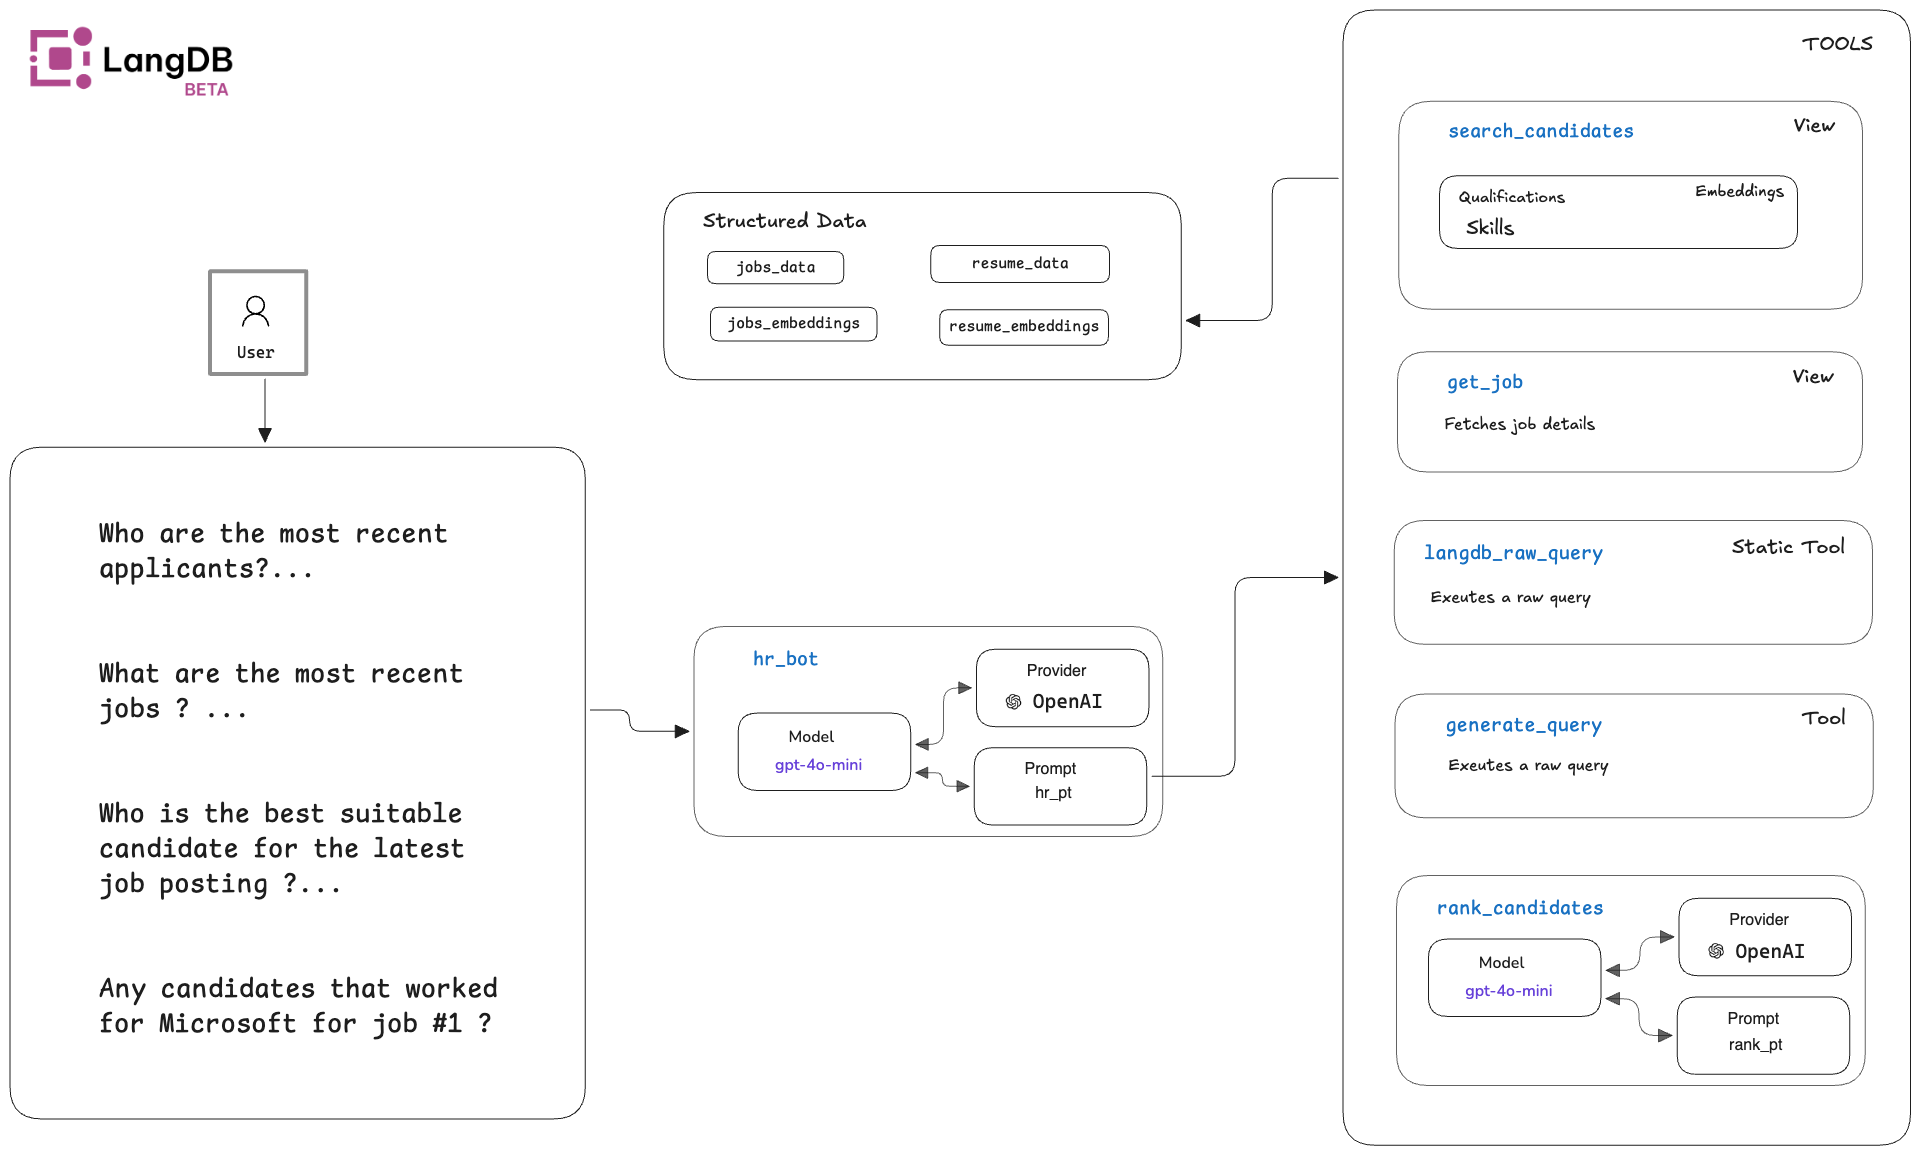

## 2) Data Extraction & Preparation Flow

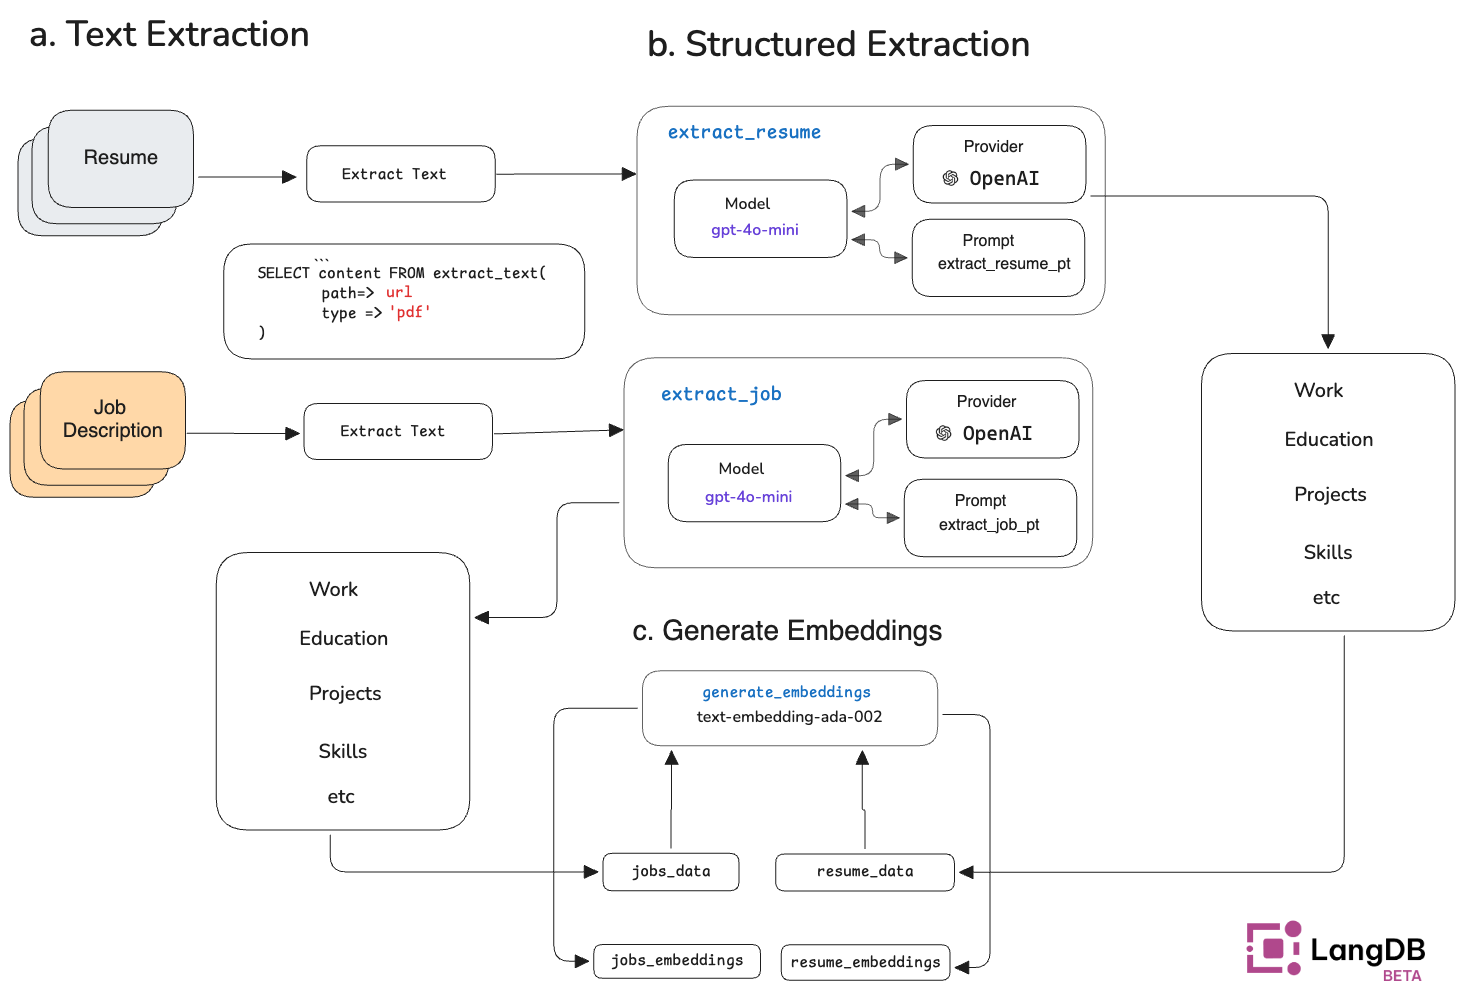

## Create Tables

We require the following tables

- `resume_data` for storing extracted resumes
- `resume_embeddings` for storing resume embeddings
- `job_data` for storing extracted jobs

#### Resume related tables

In [1]:
CREATE TABLE IF NOT EXISTS resume_data
(
    id UUID DEFAULT generateUUIDv4(),
    json String,
    full_name String MATERIALIZED JSONExtractString(json, 'Personal_Information', 'Full_Name'),
    email String MATERIALIZED JSONExtractString(json, 'Personal_Information', 'Contact_Information', 'Email'),
    phone_number String MATERIALIZED JSONExtractString(json, 'Personal_Information', 'Contact_Information', 'Phone_Number'),
    location String MATERIALIZED JSONExtractString(json, 'Personal_Information', 'Location'),
    professional_summary String MATERIALIZED JSONExtractString(json, 'Professional_Summary'),
    work_experience String MATERIALIZED JSONExtractRaw(json, 'Work_Experience'),
    education String MATERIALIZED JSONExtractRaw(json, 'Education'),
    technical_skills Array(String) MATERIALIZED JSONExtractArrayRaw(json, 'Skills_and_Competencies', 'Technical_Skills'),
    soft_skills Array(String) MATERIALIZED JSONExtractArrayRaw(json, 'Skills_and_Competencies', 'Soft_Skills'),
    earliest_start_date Date MATERIALIZED toDate( parseDateTime(concat('01/', (JSONExtractString(JSONExtractRaw(work_experience, 1), 'Start_Date'))), '%d/%m/%Y')),
    created_at DateTime default now() 
)
ENGINE = MergeTree()
ORDER BY tuple();

In [2]:
CREATE TABLE IF NOT EXISTS resume_data_raw(
    id UUID DEFAULT generateUUIDv4(),
    raw String
) ENGINE = Memory()

In [3]:
--Creating a table for storing embeddings
CREATE TABLE IF NOT EXISTS resume_embeddings (
  id UUID,
  skills_embedding Array(Float32),
  work_experience_embedding Array(Float32)
) 
ENGINE = MergeTree
ORDER BY id;

#### Job related tables

In [4]:
CREATE TABLE IF NOT EXISTS job_data_raw (
  id UInt64,
  content "String",
  metadata "String"
) 
ENGINE = MergeTree
ORDER BY (id);

In [5]:
CREATE TABLE IF NOT EXISTS job_data
(
  id UInt64 MATERIALIZED rowNumberInAllBlocks(),
    json String,
    job_title String MATERIALIZED JSONExtractString(json, 'Job_Basics', 'Job_Title'),
    company_name String MATERIALIZED JSONExtractString(json, 'Job_Basics', 'Company_Name'),
    location String MATERIALIZED JSONExtractString(json, 'Job_Basics', 'Location'),
    employment_type String MATERIALIZED JSONExtractString(json, 'Job_Basics', 'Employment_Type'),
    job_summary String MATERIALIZED JSONExtractString(json, 'Job_Summary'),
    responsibilities Array(String) MATERIALIZED JSONExtractArrayRaw(json, 'Responsibilities'),
    required_qualifications Array(String) MATERIALIZED JSONExtractArrayRaw(json, 'Requirements', 'Required_Qualifications'),
    preferred_qualifications Array(String) MATERIALIZED JSONExtractArrayRaw(json, 'Requirements', 'Preferred_Qualifications'),
    technical_skills Array(String) MATERIALIZED JSONExtractArrayRaw(json, 'Skills_and_Competencies', 'Technical_Skills'),
    soft_skills Array(String) MATERIALIZED JSONExtractArrayRaw(json, 'Skills_and_Competencies', 'Soft_Skills'),
    salary_range String MATERIALIZED JSONExtractString(json, 'Compensation_and_Benefits', 'Salary_Range'),
    benefits Array(String) MATERIALIZED JSONExtractArrayRaw(json, 'Compensation_and_Benefits', 'Benefits'),
    how_to_apply String MATERIALIZED JSONExtractString(json, 'Application_Process', 'How_to_Apply'),
    application_deadline String MATERIALIZED JSONExtractString(json, 'Application_Process', 'Application_Deadline'),
    company_description String MATERIALIZED JSONExtractString(json, 'Company_Information', 'Company_Description'),
    company_culture String MATERIALIZED JSONExtractString(json, 'Company_Information', 'Company_Culture')

)
ENGINE = MergeTree()
ORDER BY tuple();

## Create Models, Prompts, Views & Tools

We 'll create the following. 
Prompts
- `extract_resume_pt` prompt
- `extract_job_pt` prompt
- `hr_pt` prompt

Models
- `extract_resume` model
- `extract_job` model

Views
- `search_candidates` view # Returns top 5 candidtes comparing work experience and responsibilities between jobs and resumes using `cosineDistance`

Other Tools
-  `text_to_sql` model available for running raw queries against `langdb`

Final Model
- Create `hr_bot` with all the dependent models


*Explanation*
- `extract_job` and `extract_resume` are used for structured extraction
- `hr_bot` will use all the other models and tools as and when necessary based on user input. 
- We ll also several `langdb` functions through for various structured and unstructured processing.

### Create Prompts

In [6]:
CREATE PROMPT IF NOT EXISTS extract_resume_pt (
    system "You are an AI assistant specialized in extracting relevant information from resumes to match with job descriptions. Your task is to analyze the given resume text and extract key details that are typically important for job matching. Focus on the following areas:

1. Personal Information:
    - Full Name
    - Contact Information (email, phone number)
    - Location
1. Professional Summary:
   - Brief overview of professional experience and key skills

2. Work Experience:
   - Company names
   - Job titles
   - Start Date
   - End Date
   - Key responsibilities and achievements

3. Education:
   - Degrees obtained
   - Institutions attended
   - Graduation dates
   - Relevant coursework or academic achievements

4. Skills:
   - Technical skills
   - Soft skills
   - Languages
   - Certifications

Instructions:
1. Analyze the provided resume text carefully.
2. Extract the information for each category listed above.
3. Organize the extracted information in a structured format.
4. If certain information is not available in the resume, indicate it as 'Not provided' for that category.
5. Pay special attention to skills, technologies, and experiences that are commonly sought after in job descriptions.
6. Highlight any unique selling points or standout achievements in the resume.
7. Provide a brief summary of the candidate's overall profile based on the extracted information.

Output Format:
Present the extracted information in a structured JSON format for easy parsing and integration with job matching algorithms. Include a 'summary' field with a brief overview of the candidate's profile.
- Important: To ensure compatibility with ClickHouse JSON parsing, follow these additional guidelines:
 a.  Strictly return Response will be directly fed to a json parser. 
Replace any newline characters within string values with the escaped newline sequence (\n).
    
Follow the following schema:

1. Personal_Information (Object):
   - Full_Name (String): The individual's complete name. If its not provided, Generate a Name
   - Contact_Information (Object): If its not provided, Generate  Information
   - Email (String): The individual's email address. If its not provided, Generate  email
   - Phone_Number (String): The individual's contact phone number. If its not provided, Generate  Phone_number
   - Location (String): The individual's current location or address. If its not provided, Generate  Location
2. Professional_Summary (String): 
   A brief overview of the individual's professional background and key skills.

3. Work_Experience (Array of Objects):
   Each object contains:
   - Company (String): Name of the employer
   - Job_Title (String): Position held
   - Start_Date (MM/YYYY): 
        - Starting Date of the Company. If not in that format put 01/2022
   - End_Date (MM/YYYY): Ending Date of the Company . If not in that format put 01/2022
   - Key_Responsibilities (Array of Strings): List of main duties
   - Achievements (Array of Strings): List of accomplishments in the role

4. Education (Array of Objects):
   Each object contains:
   - Degree (String): Type of degree or education
   - Field (String): Area of study
   - Institution (String): Name of the educational institution
   - Graduation_Date (String, optional): Year of graduation
   - GPA (String, optional): Grade Point Average
   - Relevant_Credits (String, optional): Additional educational details

5. Skills_and_Competencies (Object):
   - Technical_Skills (Array of Strings)
   - Soft_Skills (Array of Strings)



Note: All fields are required unless marked as optional.
Strictly return Response will be directly fed to a json parser. 
Remember to adapt and extract information based on the specific job description provided, focusing on elements that are most relevant for candidate matching. Ensure all output follows this single-line JSON format to maintain ClickHouse compatibility.",
    human "{{input}}")

In [ ]:
CREATE PROMPT extract_job_pt(
    system "You are an AI assistant designed to extract key information from job descriptions. Analyze the given job posting text and extract the following details:

1. Job_Basics (Object):
   - Job_Title (String): Title of the position
   - Company_Name (String): Name of the company offering the job
   - Location (String): Job location, including remote options
   - Employment_Type (String): Full-time, part-time, contract, etc.

2. Job_Summary (String):
   Brief overview of the role and its place in the organization

3. Responsibilities (Array of Strings):
   Key duties and tasks of the role

4. Requirements (Object):
   - Required_Qualifications (Array of Strings): Required education, experience, and skills
   - Preferred_Qualifications (Array of Strings): Desired but not mandatory qualifications

5. Skills_and_Competencies (Object):
   - Technical_Skills (Array of Strings): Required technical skills
   - Soft_Skills (Array of Strings): Required soft skills

6. Compensation_and_Benefits (Object):
   - Salary_Range (String): Salary information if provided
   - Benefits (Array of Strings): List of benefits and perks

7. Application_Process (Object):
   - How_to_Apply (String): Instructions for application submission
   - Application_Deadline (String): Deadline for applications, if mentioned
perience with data analytics tools 
8. Company_Information (Object):
   - Company_Description (String): Brief description of the company
   - Company_Culture (String): Information about company culture or values

9. Keywords (Array of Strings):
   Industry-specific terms, tools, and technologies mentioned

Instructions:
1. Extract information for each category from the job description.
2. If information is not available, use 'Not provided' for string fields and an empty array [] for array fields.
3. Focus on details relevant for candidate matching.
4. Present the extracted information in a structured JSON format.

Output Format:
Present the extracted information in a structured JSON format for easy parsing and integration with resume matching algorithms.


Strictly return Response will be directly fed to a json parser. 
Remember to adapt and extract information based on the specific job description provided, focusing on elements that are most relevant for candidate matching. Ensure all output follows this single-line JSON format to maintain ClickHouse compatibility.",
    human "{{input}}")

In [2]:
CREATE PROMPT IF NOT EXISTS hr_pt(
    system "You are an HR Bot, Your job is to answer queries about candidates and jobs. 

    There are mainly two scenarios. 
    1) You perform a raw query against the tables mentioned below using the text_to_sql tool
        You can search for jobs using this. When searching for Jobs, Mention ID
    2) You use the search_candidates tool to recommend the right candidates for the job. 
    
    Tables available: 
    1. resume_data:          
    2. job_data:

    Information on the tools:
            
        a. search_candidates:
            input: (Required_Skills required ,work_experience required)
            Searching the candidates using vector search over candidates Skills and work_experience
            Output is top 5 candidate
        b. text_to_sql:
            Tool to run a clickhouse SELECT SQL query on resume_data and job table to get:
                resume_data:
                    earliest_start_date and created_at columns

                job_data:
                    jobs details with their id. Mention Job ID.
    
            If matching on job_title use a lower case
Note: To get years of experience get earliest_start_date and current date and calculcate the difference.
      Mention Job ID.
Output Format:
   Present the results in a JSON. Include the following information:
   Present the following information only if recommending candidates
   a. Job Information:
      - Provide a summary of the extracted job information. 
      - Mention Job ID.
    If something isnt provided generate based on the context
   
   b. Top Candidates:
      - List the top candidates (up to 5) with the following details for each:
        * Candidate ID
        * Name: 
        * Work experience match score (0-100)
        * Skills match score (0-100)
        * Overall rank
        * Brief explanation of ranking
   
   c. Most Suitable Candidate:
      - Provide detailed information about the most suitable candidate, including:
        * Candidate ID
        * Name
        * Work experience match score (0-100)
        * Skills match score (0-100)
        * Overall rank
        * Detailed explanation of why this candidate is most suitable",

    
    human "{{question}}"
)
            

### Create Models

In [ ]:
CREATE EMBEDDING MODEL generate_embeddings 
USING openai(model='text-embedding-ada-002', encoding_format='float')

In [15]:
CREATE MODEL IF NOT EXISTS  extract_resume (input)
USING openai(model_name= 'gpt-4o-mini')
PROMPT extract_resume_pt
OUTPUT_SCHEMA '{
  "type": "object",
  "additionalProperties": false,
  "properties": {
    "Personal_Information": {
      "type": "object",
      "additionalProperties": false,
      "properties": {
        "Full_Name": { "type": "string" },
        "Contact_Information": {
          "type": "object",
          "additionalProperties": false,
          "properties": {
            "Email": { "type": "string" },
            "Phone_Number": { "type": "string" }
          },
          "required": ["Email", "Phone_Number"]
        },
        "Location": { "type": "string" }
      },
      "required": ["Full_Name", "Contact_Information", "Location"]
    },
    "Professional_Summary": { "type": "string" },
    "Work_Experience": {
      "type": "array",
      "items": {
        "type": "object",
        "additionalProperties": false,
        "properties": {
          "Company": { "type": "string" },
          "Job_Title": { "type": "string" },
          "Start_Date": { "type": "string" },
          "End_Date": { "type": "string" },
          "Key_Responsibilities": {
            "type": "array",
            "items": { "type": "string" }
          },
          "Achievements": {
            "type": "array",
            "items": { "type": "string" }
          }
        },
        "required": ["Company", "Job_Title", "Start_Date", "End_Date", "Key_Responsibilities", "Achievements"]
      }
    },
    "Education": {
      "type": "array",
      "items": {
        "type": "object",
        "additionalProperties": false,
        "properties": {
          "Degree": { "type": "string" },
          "Field": { "type": "string" },
          "Institution": { "type": "string" }
        },
        "required": ["Degree", "Field", "Institution"]
      }
    },
    "Skills_and_Competencies": {
      "type": "object",
      "additionalProperties": false,
      "properties": {
        "Technical_Skills": {
          "type": "array",
          "items": { "type": "string" }
        },
        "Soft_Skills": {
          "type": "array",
          "items": { "type": "string" }
        }
      },
      "required": ["Technical_Skills", "Soft_Skills"]
    }
  },
  "required": ["Personal_Information", "Professional_Summary", "Work_Experience", "Education", "Skills_and_Competencies"]
}' ;

Model already present

In [18]:
CREATE MODEL IF NOT EXISTS extract_job(input) 
    USING openai(model='gpt-4o-mini')
PROMPT extract_job_pt
OUTPUT_SCHEMA '{
  "type": "object",
  "additionalProperties": false,
  "properties": {
    "Job_Basics": {
      "type": "object",
      "additionalProperties": false,
      "properties": {
        "Job_Title": { "type": "string" },
        "Company_Name": { "type": "string" },
        "Location": { "type": "string" },
        "Employment_Type": { "type": "string" }
      },
      "required": ["Job_Title", "Company_Name", "Location", "Employment_Type"]
    },
    "Job_Summary": { "type": "string" },
    "Responsibilities": {
      "type": "array",
      "items": { "type": "string" }
    },
    "Requirements": {
      "type": "object",
      "additionalProperties": false,
      "properties": {
        "Required_Qualifications": {
          "type": "array",
          "items": { "type": "string" }
        },
        "Preferred_Qualifications": {
          "type": "array",
          "items": { "type": "string" }
        }
      },
      "required": ["Required_Qualifications", "Preferred_Qualifications"]
    },
    "Skills_and_Competencies": {
      "type": "object",
      "additionalProperties": false,
      "properties": {
        "Technical_Skills": {
          "type": "array",
          "items": { "type": "string" }
        },
        "Soft_Skills": {
          "type": "array",
          "items": { "type": "string" }
        }
      },
      "required": ["Technical_Skills", "Soft_Skills"]
    },
    "Compensation_and_Benefits": {
      "type": "object",
      "additionalProperties": false,
      "properties": {
        "Salary_Range": { "type": "string" },
        "Benefits": {
          "type": "array",
          "items": { "type": "string" }
        }
      },
      "required": ["Salary_Range", "Benefits"]
    },
    "Application_Process": {
      "type": "object",
      "additionalProperties": false,
      "properties": {
        "How_to_Apply": { "type": "string" },
        "Application_Deadline": { "type": "string" }
      },
      "required": ["How_to_Apply", "Application_Deadline"]
    },
    "Company_Information": {
      "type": "object",
      "additionalProperties": false,
      "properties": {
        "Company_Description": { "type": "string" },
        "Company_Culture": { "type": "string" }
      },
      "required": ["Company_Description", "Company_Culture"]
    },
    "Keywords": {
      "type": "array",
      "items": { "type": "string" }
    }
  },
  "required": [
    "Job_Basics",
    "Job_Summary",
    "Responsibilities",
    "Requirements",
    "Skills_and_Competencies",
    "Compensation_and_Benefits",
    "Application_Process",
    "Company_Information",
    "Keywords"
  ]
}'

### Create Views

In [29]:
CREATE VIEW IF NOT EXISTS search_candidates(skills String, work_experience String) AS
WITH tbl1 AS (
  SELECT embedding::Array(Float32) AS skills_embeddings FROM generate_embeddings($skills) 
),
tbl2 AS (
  SELECT embedding::Array(Float32) AS work_ex_embeddings FROM generate_embeddings($work_experience) 
)   
SELECT 
    p.professional_summary, 
    p.work_experience, 
    p.technical_skills, 
    p.soft_skills,
    cosineDistance(
        work_experience_embedding,
        work_ex_embeddings
    ) AS work_experience_distance,
    cosineDistance(
        skills_embedding,
        skills_embeddings
    ) AS skills_distance 

FROM 
  resume_embeddings AS pe 
JOIN 
  resume_data AS p ON p.id = pe.id
CROSS JOIN
  tbl1
CROSS JOIN tbl2
ORDER BY 
  skills_distance * work_experience_distance ASC 
  LIMIT 5


## Exploring Data

#### Loading Data

In [13]:
INSERT INTO resume_data_raw(raw)
select content as text from extract_text((
    select content as file from load((
            select arrayJoin([
    'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ACCOUNTANT/12202337.pdf',
    'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ACCOUNTANT/14470533.pdf',
    'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ACCOUNTANT/15821633.pdf',
    'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ACCOUNTANT/23416654.pdf',
    'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ACCOUNTANT/20253563.pdf',
    'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ACCOUNTANT/20345168.pdf',
    'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ACCOUNTANT/20393721.pdf',
    'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ACCOUNTANT/20624984.pdf',
    'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ACCOUNTANT/21031285.pdf',
    'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ACCOUNTANT/21338490.pdf', 
    'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ACCOUNTANT/23513618.pdf',
    'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ACCOUNTANT/23636277.pdf',
    'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ACCOUNTANT/23734441.pdf',
    'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ACCOUNTANT/24103168.pdf',
    'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ACCOUNTANT/24294778.pdf',
    'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ACCOUNTANT/25067742.pdf',
    'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ACCOUNTANT/25127518.pdf',
    'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ACCOUNTANT/25547145.pdf',
    'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ACCOUNTANT/25846894.pdf',
    'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ACCOUNTANT/26065877.pdf',
    'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ACCOUNTANT/27573855.pdf', --
    'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ACCOUNTANT/31602598.pdf',
    'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ACCOUNTANT/33527446.pdf',
    'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ACCOUNTANT/34198885.pdf',
    'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ACCOUNTANT/34816637.pdf',
    'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ACCOUNTANT/36425270.pdf',
    'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ACCOUNTANT/37997506.pdf']) 
    ))
),
path => file, type => 'pdf') 

In [ ]:
INSERT INTO resume_data_raw(raw)
select content from extract_text((
    select content as file from load((
            select arrayJoin([
     'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ENGINEERING/10030015.pdf',
     'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ENGINEERING/10219099.pdf',
     'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ENGINEERING/10624813.pdf',
     'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ENGINEERING/10712803.pdf',
     'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ENGINEERING/10985403.pdf',
     'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ENGINEERING/11890896.pdf',
     'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ENGINEERING/11981094.pdf',
     'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ENGINEERING/12011623.pdf',
     'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ENGINEERING/12022566.pdf',
     'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ENGINEERING/12472574.pdf',
     'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ENGINEERING/12488356.pdf',
     'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ENGINEERING/12518008.pdf',
     'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ENGINEERING/12748557.pdf',
     'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ENGINEERING/13149176.pdf',
     'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ENGINEERING/13264796.pdf',
     'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ENGINEERING/14049846.pdf',
     'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ENGINEERING/14206561.pdf',
     'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ENGINEERING/14554542.pdf',
     'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ENGINEERING/15139979.pdf',
     'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ENGINEERING/15601399.pdf',
     'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ENGINEERING/15858254.pdf',
     'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ENGINEERING/15941675.pdf',
     'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ENGINEERING/16803215.pdf',
     'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ENGINEERING/16911115.pdf',
     'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ENGINEERING/17103000.pdf',
     'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ENGINEERING/17108676.pdf',
     'https://langdb-sample-data.s3.ap-southeast-1.amazonaws.com/ENGINEERING/17488801.pdf'
]) 
    ))
),
path => file, type => 'pdf') 

In [18]:
SELECT * FROM extract_resume(
    (SELECT raw from resume_data_raw limit 1),
    input => raw
) 

{"Education":[{"Degree":"Master of Business Administration","Field":"Finance","Institution":"University of Delaware"},{"Degree":"Bachelor of Science","Field":"Medical Technology","Institution":"University of Delaware"}],"Personal_Information":{"Contact_Information":{"Email":"generated_email@example.com","Phone_Number":"(123) 456-7890"},"Full_Name":"Generated Name","Location":"Generated Location"},"Professional_Summary":"Accomplished and results oriented Investment professional with strong leadership and interpersonal skills who adds energy and value to an organization’s quest for excellence.","Skills_and_Competencies":{"Soft_Skills":["Detail-oriented","Effective time management","Complex problem solving","Superior research skills","Excellent multitasking","Analytical thinking","Negotiation","Communication","Organization","Leadership"],"Technical_Skills":["MS Office Suite (Excel, Word, PowerPoint, Database, Macros, V-look up, Pivot tables, Outlook)","Business Objects","Lombardi","Eagle 

In [ ]:
INSERT INTO resume_data(id, json)
SELECT id, output from extract_resume(
    (SELECT p.id, raw FROM resume_data_raw AS p LEFT JOIN resume_data AS pe ON p.id = pe.id
WHERE p.id != pe.id
ORDER BY p.id
),
    input => raw)

Job data extraction

In [7]:
INSERT INTO job_data_raw(content,metadata )
select content, metadata from extract_text((
    select content as file from load((
            select arrayJoin([
                            'https://www.atpuk.co.uk/images/pdfs/Mobile-App-Developer.pdf',
                            'https://hr.mcmaster.ca/app/uploads/2019/01/JD00035-Applications-Developer-1-46.pdf',
                            'https://www.aii.ac.in/wp-content/uploads/2023/01/Job-Position-Web-Developer.pdf'
        ]) 
    ))
),
    path => file, type => 'PDF')

In [19]:
SELECT * FROM extract_job(
    (SELECT content from job_data_raw limit 1),
    input => content
) 

{"Application_Process":{"Application_Deadline":"Not provided","How_to_Apply":"Not provided"},"Company_Information":{"Company_Culture":"Not provided","Company_Description":"Pipeline Integrity Management"},"Compensation_and_Benefits":{"Benefits":[],"Salary_Range":"Not provided"},"Job_Basics":{"Company_Name":"Associated Technology Pipeline","Employment_Type":"Not provided","Job_Title":"Not provided","Location":"Not provided"},"Job_Summary":"Not provided","Keywords":[],"Requirements":{"Preferred_Qualifications":[],"Required_Qualifications":[]},"Responsibilities":[], "Skills_and_Competencies":{"Soft_Skills":[],"Technical_Skills":[]}}

In [28]:
INSERT INTO job_data(json)
SELECT output from extract_job(
    (SELECT content from job_data_raw),
    input => content)

In [6]:
INSERT INTO resume_embeddings
WITH skills_embeddings AS (
    SELECT 
        id,
        embedding AS skills_embedding
    FROM generate_embeddings((
        SELECT 
            id,
            arrayStringConcat(arrayConcat(
                JSONExtractArrayRaw(json, 'Skills_and_Competencies', 'Technical_Skills'),
                JSONExtractArrayRaw(json, 'Skills_and_Competencies', 'Soft_Skills')
            ), ', ') AS all_skills
        FROM resume_data
    ),
    input => all_skills)
),
work_experience_embeddings AS (
    SELECT 
        id,
        embedding AS work_experience_embeddings
    FROM generate_embeddings((
        SELECT 
            id,
            JSONExtractString(json, 'Work_Experience') AS work_experience_text
        FROM resume_data
    ),
    input => work_experience_text)
)
SELECT 
    rd.id,
    se.skills_embedding,
    we.work_experience_embeddings AS work_experience_embedding
FROM resume_data rd
LEFT JOIN skills_embeddings se ON rd.id = se.id
LEFT JOIN work_experience_embeddings we ON rd.id = we.id
LEFT JOIN resume_embeddings AS pe ON rd.id = pe.id
WHERE rd.id != pe.id OR pe.id IS NULL
ORDER BY rd.id

## HR Assistant

In [31]:
CREATE MODEL IF NOT EXISTS hr_bot(
    question
)
USING openai(model_name = 'gpt-4o-mini')
PROMPT hr_pt 
TOOLS (
    text_to_sql COMMENT 'Tool to query resume_data 
    and job_data tables',
    search_candidates COMMENT 'Search Candidates over skills and experience 
    based on user input. Both are required fields'
)

In [32]:
SELECT * FROM hr_bot('who are the 2 most recent applicants')

```json
{
  "recent_applicants": [
    {
      "Candidate ID": "7912d99a-a185-48e4-a5e6-ea1316dd9cd5",
      "Name": "Not provided",
      "Email": "email@example.com",
      "Phone Number": "123-456-7890",
      "Location": "City, State",
      "Professional Summary": "Senior Software Executive with over 17 years of experience in agile software development and strategic planning. Proven track record of aligning engineering teams with business goals and driving software improvements that maximize profitability and scalability."
    },
    {
      "Candidate ID": "6c2954ef-23cc-44be-a6d4-55cbd03783e2",
      "Name": "Not provided",
      "Email": "email@example.com",
      "Phone Number": "123-456-7890",
      "Location": "City, State",
      "Professional Summary": "A motivated engineering intern with hands-on experience in the field of chemical engineering and systems engineering. Skilled in process design, quality control, and statistical process control, seeking a challenging positi

In [42]:
SELECT * FROM hr_bot('what are the job positions are available')

Here are the available job positions:

```json
{
  "job_positions": [
    {
      "id": "0",
      "job_title": "Not provided"
    },
    {
      "id": "1",
      "job_title": "Application Developer"
    },
    {
      "id": "2",
      "job_title": "Full Stack Developer"
    }
  ]
}
```

In [37]:
SELECT * FROM hr_bot('give me people who worked on microsoft tech with experience of 4 years for jobid 0')

```json
{
  "Job Information": {
    "Job ID": 0,
    "Company Name": "Associated Technology Pipeline",
    "Company Description": "Associated Technology Pipeline is involved in Pipeline Integrity Management.",
    "Job Title": "Not provided",
    "Location": "Not provided"
  },
  "Top Candidates": [
    {
      "Candidate ID": "1",
      "Name": "Candidate A",
      "Work experience match score": 86,
      "Skills match score": 77,
      "Overall rank": 1,
      "Brief explanation of ranking": "Candidate A has extensive relevant experience and a strong match on technical skills, particularly with Microsoft technologies."
    },
    {
      "Candidate ID": "2",
      "Name": "Candidate B",
      "Work experience match score": 84,
      "Skills match score": 75,
      "Overall rank": 2,
      "Brief explanation of ranking": "Candidate B shows a solid background in related technologies and considerable work experience."
    },
    {
      "Candidate ID": "3",
      "Name": "Candidate C",

In [44]:
SELECT * FROM hr_bot('Find me developers that have 2 years of experience with microsoft technologies that have done scripting before')

```json
{
  "Top_Candidates": [
    {
      "Candidate_ID": 1,
      "Name": "Candidate 1",
      "Work_experience_match_score": 85,
      "Skills_match_score": 80,
      "Overall_rank": 1,
      "Explanation": "This candidate has a strong background in both Microsoft technologies and scripting, with excellent relevant experience."
    },
    {
      "Candidate_ID": 2,
      "Name": "Candidate 2",
      "Work_experience_match_score": 80,
      "Skills_match_score": 78,
      "Overall_rank": 2,
      "Explanation": "While they have relevant skills, their work experience slightly exceeds the requested amount, yet they have strong technical abilities."
    },
    {
      "Candidate_ID": 3,
      "Name": "Candidate 3",
      "Work_experience_match_score": 75,
      "Skills_match_score": 75,
      "Overall_rank": 3,
      "Explanation": "This candidate has a good mix of skills and experience but could be enhanced with more direct exposure to Microsoft technologies."
    },
    {
      "Cand